In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, f1_score

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

!gdown --id 1lMGQHFRHhZA59ZSKhyzRRKIAELlzMxJ7


print("File successfully uploaded to:", os.path.abspath("1lMGQHFRHhZA59ZSKhyzRRKIAELlzMxJ7"))

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1lMGQHFRHhZA59ZSKhyzRRKIAELlzMxJ7
To: /content/emotion_model_weights.pth
100% 11.7M/11.7M [00:00<00:00, 106MB/s]
File successfully uploaded to: /content/1lMGQHFRHhZA59ZSKhyzRRKIAELlzMxJ7


In [11]:
!cp "/content/drive/MyDrive/Dataset.zip" "/content/Dataset.zip"

In [13]:
!unzip -q Dataset.zip

replace FER-2013/test/angry/image0000006.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [15]:
train_dir = "FER-2013/train"
test_dir = "FER-2013/test"

classes = sorted(os.listdir(train_dir))
counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in classes}
counts

{'angry': 3995,
 'disgust': 436,
 'fear': 4097,
 'happy': 7215,
 'neutral': 4965,
 'sad': 4830,
 'surprise': 3171}

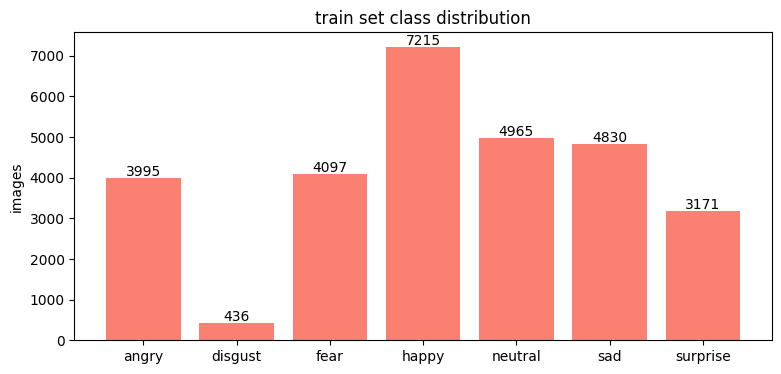

imbalance ratio (max/min): 16.55


In [16]:
plt.figure(figsize=(9, 4))
bars = plt.bar(counts.keys(), counts.values(), color="salmon")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 50, int(b.get_height()), ha="center")
plt.title("train set class distribution")
plt.ylabel("images")
plt.show()

print("imbalance ratio (max/min):", round(max(counts.values()) / min(counts.values()), 2))

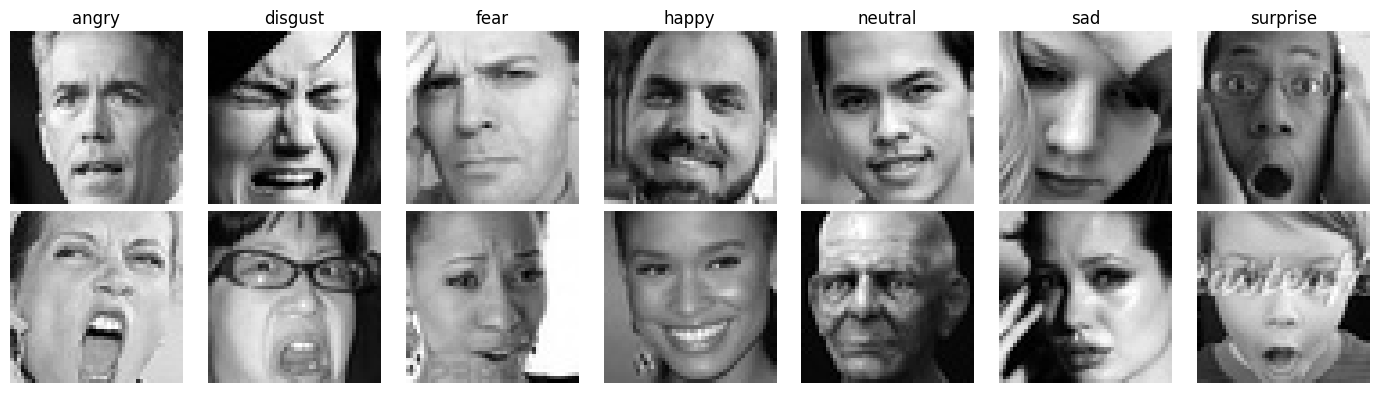

In [17]:
fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for i, c in enumerate(classes):
    files = os.listdir(os.path.join(train_dir, c))[:2]
    for j in range(2):
        img = plt.imread(os.path.join(train_dir, c, files[j]))
        axes[j][i].imshow(img, cmap="gray")
        axes[j][i].axis("off")
        if j == 0:
            axes[j][i].set_title(c)
plt.tight_layout()
plt.show()

## data loading

In [18]:
train_tfms = transforms.Compose([
    transforms.Resize((48, 48)),  # <-- ADDED FIX: Forces all training images to uniform size
    transforms.Grayscale(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_tfms = transforms.Compose([
    transforms.Resize((48, 48)),  # <-- ADDED FIX: Forces all test/val images to uniform size
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train = datasets.ImageFolder(train_dir, transform=train_tfms)
full_train_noaug = datasets.ImageFolder(train_dir, transform=test_tfms)
test_ds = datasets.ImageFolder(test_dir, transform=test_tfms)

val_size = int(0.1 * len(full_train))
perm = torch.randperm(len(full_train)).tolist()
train_idx, val_idx = perm[val_size:], perm[:val_size]

train_ds = Subset(full_train, train_idx)
val_ds = Subset(full_train_noaug, val_idx)

print(f"Dataset sizes - Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

targets = np.array(full_train.targets)
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts

sample_weights = class_weights[targets[train_ds.indices]]
sampler = WeightedRandomSampler(torch.from_numpy(sample_weights).double(), len(sample_weights))

train_dl = DataLoader(train_ds, batch_size=64, sampler=sampler)
val_dl = DataLoader(val_ds, batch_size=128)
test_dl = DataLoader(test_ds, batch_size=128)

# sanity check that batches are actually balanced now
xb, yb = next(iter(train_dl))
print("Batch class distribution check:", dict(zip(classes, np.bincount(yb.numpy(), minlength=7))))

Dataset sizes - Train: 25839, Val: 2870, Test: 20384
Batch class distribution check: {'angry': np.int64(12), 'disgust': np.int64(9), 'fear': np.int64(10), 'happy': np.int64(13), 'neutral': np.int64(12), 'sad': np.int64(4), 'surprise': np.int64(4)}


In [19]:
targets = np.array(full_train.targets)
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts

sample_weights = class_weights[targets[train_ds.indices]]
sampler = WeightedRandomSampler(torch.from_numpy(sample_weights).double(), len(sample_weights))

train_dl = DataLoader(train_ds, batch_size=64, sampler=sampler)
val_dl = DataLoader(val_ds, batch_size=128)
test_dl = DataLoader(test_ds, batch_size=128)

## focal loss

not adding class alpha weights here since the sampler is already balancing the batches, doing both would over correct. gamma=2 is the standard value from the paper.

In [20]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

class EmotionCNN(nn.Module):
    def __init__(self, n_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = EmotionCNN().to(device)
print(f"Total model parameters: {sum(p.numel() for p in model.parameters())}")

Total model parameters: 2916807


In [21]:
def get_preds(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())
    return np.array(preds), np.array(labels)


weights_path = "/content/emotion_model_weights.pth"

model.load_state_dict(torch.load(weights_path, map_location=device))

model.eval()

EmotionCNN(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.25,

  batch 100/404  avg loss 1.4677
  batch 200/404  avg loss 1.4439
  batch 300/404  avg loss 1.4271
  batch 400/404  avg loss 1.4091
epoch 01/20  loss 1.4085  val_macro_f1 0.1342
  batch 100/404  avg loss 1.3431
  batch 200/404  avg loss 1.3350
  batch 300/404  avg loss 1.3300
  batch 400/404  avg loss 1.3271
epoch 02/20  loss 1.3268  val_macro_f1 0.1719
  batch 100/404  avg loss 1.2954
  batch 200/404  avg loss 1.2942
  batch 300/404  avg loss 1.2944
  batch 400/404  avg loss 1.2969
epoch 03/20  loss 1.2968  val_macro_f1 0.1812
  batch 100/404  avg loss 1.2847
  batch 200/404  avg loss 1.2739
  batch 300/404  avg loss 1.2667
  batch 400/404  avg loss 1.2564
epoch 04/20  loss 1.2562  val_macro_f1 0.2364
  batch 100/404  avg loss 1.2222
  batch 200/404  avg loss 1.2136
  batch 300/404  avg loss 1.2074
  batch 400/404  avg loss 1.2049
epoch 05/20  loss 1.2042  val_macro_f1 0.3193
  batch 100/404  avg loss 1.1671
  batch 200/404  avg loss 1.1686
  batch 300/404  avg loss 1.1679
  batch 400

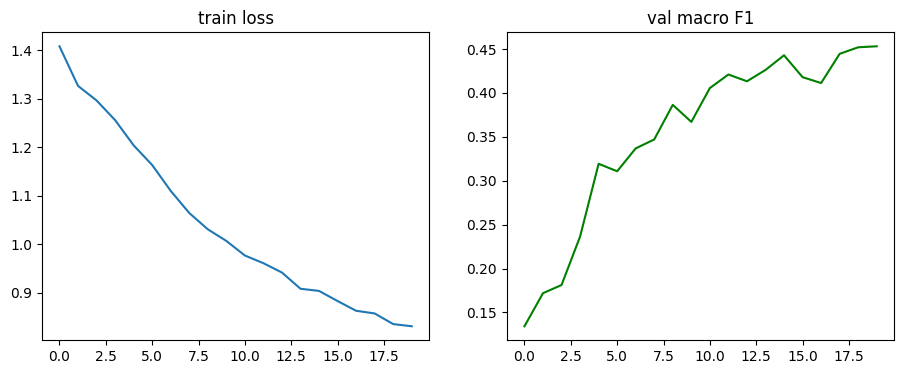

In [ ]:
def get_preds(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())
    return np.array(preds), np.array(labels)

crit = FocalLoss(gamma=2.0)
opt = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)

epochs = 20
best_f1 = 0
history = {"train_loss": [], "val_f1": []}

for ep in range(epochs):
    model.train()
    running = 0
    for i, (x, y) in enumerate(train_dl):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = crit(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        running += loss.item()
        if (i + 1) % 100 == 0:
            print(f"  batch {i+1}/{len(train_dl)}  avg loss {running/(i+1):.4f}")

    train_loss = running / len(train_dl)
    val_preds, val_labels = get_preds(model, val_dl)
    val_f1 = f1_score(val_labels, val_preds, average="macro")
    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["val_f1"].append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_fer_model.pth")

    print(f"epoch {ep+1:02d}/{epochs}  loss {train_loss:.4f}  val_macro_f1 {val_f1:.4f}")

print("best val macro f1:", round(best_f1, 4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"])
ax[0].set_title("train loss")
ax[1].plot(history["val_f1"], color="green")
ax[1].set_title("val macro F1")
plt.show()

              precision    recall  f1-score   support

       angry       0.34      0.22      0.27      2676
     disgust       0.30      0.20      0.24      1359
        fear       0.32      0.10      0.15      2688
       happy       0.71      0.76      0.73      4478
     neutral       0.34      0.48      0.40      3601
         sad       0.24      0.40      0.30      2831
    surprise       0.51      0.40      0.45      2751

    accuracy                           0.42     20384
   macro avg       0.39      0.37      0.36     20384
weighted avg       0.42      0.42      0.41     20384



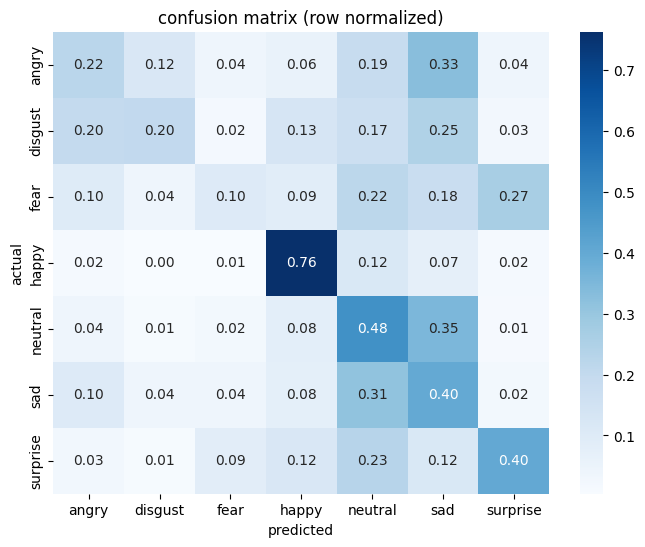

In [22]:
test_preds, test_labels = get_preds(model, test_dl)

print(classification_report(test_labels, test_preds, target_names=classes))

cm = confusion_matrix(test_labels, test_preds, normalize="true")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix (row normalized)")
plt.show()

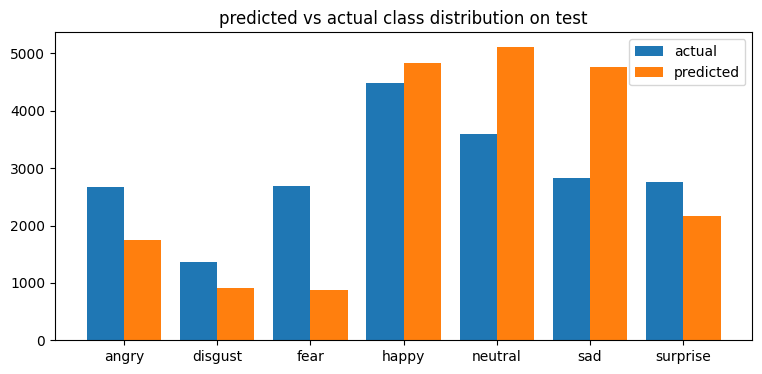

In [23]:
pred_dist = np.bincount(test_preds, minlength=7)
actual_dist = np.bincount(test_labels, minlength=7)

x = np.arange(7)
plt.figure(figsize=(9, 4))
plt.bar(x - 0.2, actual_dist, 0.4, label="actual")
plt.bar(x + 0.2, pred_dist, 0.4, label="predicted")
plt.xticks(x, classes)
plt.legend()
plt.title("predicted vs actual class distribution on test")
plt.show()

In [26]:
pip install grad-cam opencv-python pillow matplotlib numpy

Opening webcam to capture 5 images with Grad-CAM analysis...


<IPython.core.display.Javascript object>

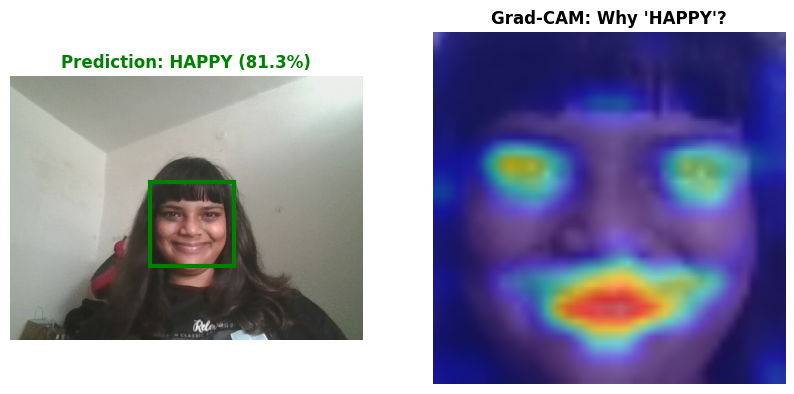

<IPython.core.display.Javascript object>

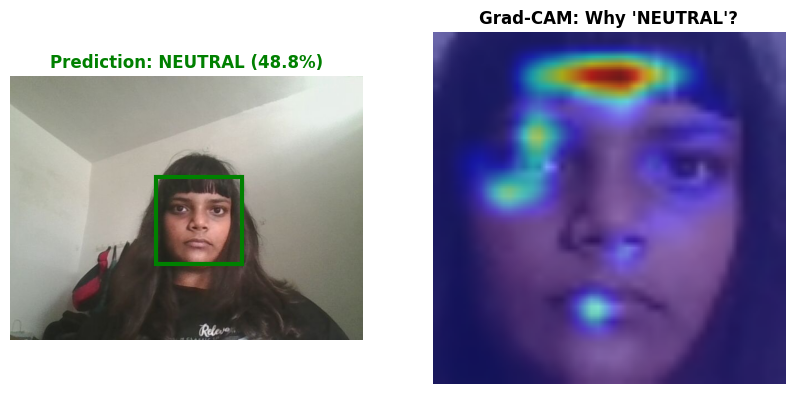

<IPython.core.display.Javascript object>

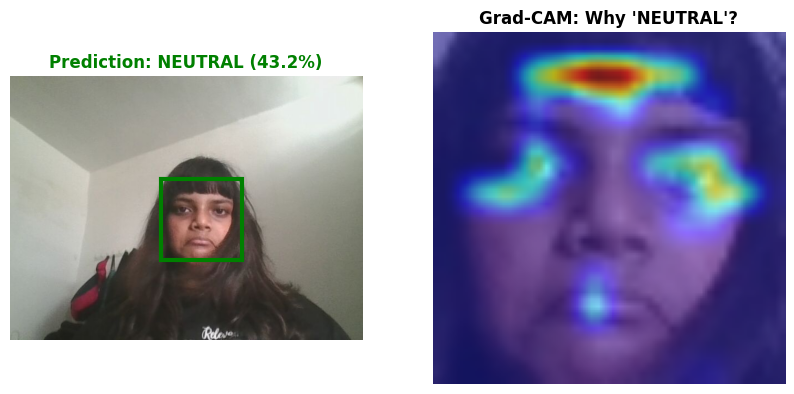

<IPython.core.display.Javascript object>

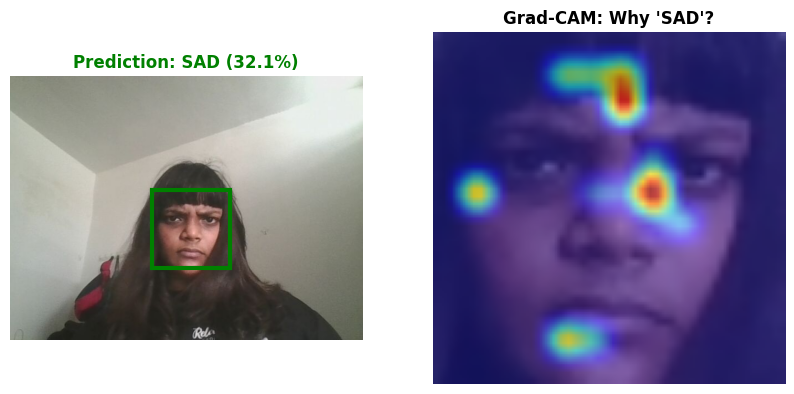

<IPython.core.display.Javascript object>

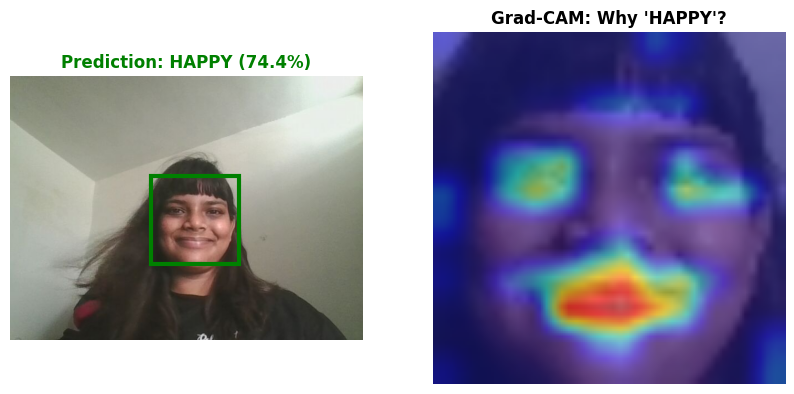

Session complete!


In [28]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
import io
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# --- NEW IMPORTS FOR GRAD-CAM ---
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 1. The Javascript webcam function (Unchanged)
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture Face for Grad-CAM';
            capture.style.padding = '10px 20px';
            capture.style.fontSize = '16px';
            capture.style.background = '#4CAF50';
            capture.style.color = 'white';
            capture.style.border = 'none';
            capture.style.cursor = 'pointer';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            video.style.margin = '10px 0';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


# 2. Setup OpenCV Face Detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 3. SETUP GRAD-CAM
# We must tell Grad-CAM which layer to look at.
# In your EmotionCNN, the layers are inside self.features.
# We want the LAST Conv2d layer, which is at index 14 in your Sequential block.
target_layers = [model.features[14]]
cam = GradCAM(model=model, target_layers=target_layers) # We don't use use_cuda flag anymore in newer library versions

# Ensure model is ready
model.eval()

num_captures = 5

print(f"Opening webcam to capture {num_captures} images with Grad-CAM analysis...")

for i in range(num_captures):
    try:
        filename = take_photo(f'capture_{i}.jpg')
        img = cv2.imread(filename)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Detect face
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if len(faces) == 0:
            print("No face detected! Try again.")
            continue

        (x, y, w, h) = faces[0]
        face_crop = img_rgb[y:y+h, x:x+w]
        face_pil = Image.fromarray(face_crop)

        # 4. Prepare input tensor for the model
        input_tensor = test_tfms(face_pil).unsqueeze(0).to(device)

        # 5. Get Model Prediction (Standard)
        with torch.no_grad():
            outputs = model(input_tensor)
            probabilities = F.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)
            pred_idx = predicted.item()
            emotion = classes[pred_idx]
            conf_score = confidence.item() * 100

        # 6. GENERATE GRAD-CAM HEATMAP
        # We target the class the model just predicted to see *why* it predicted it
        targets = [ClassifierOutputTarget(pred_idx)]

        # Generate the grayscale CAM map (values between 0 and 1)
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

        # 7. OVERLAY HEATMAP ON THE FACE
        # To use show_cam_on_image, the image must be a float32 array between 0 and 1
        face_crop_float = np.float32(cv2.resize(face_crop, (48, 48))) / 255.0

        # Overlay the heatmap
        cam_image = show_cam_on_image(face_crop_float, grayscale_cam, use_rgb=True)

        # Resize back up to the original crop size for display
        cam_image_resized = cv2.resize(cam_image, (w, h))

        # 8. PLOT RESULTS SIDE-BY-SIDE
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Plot 1: Original Image with Bounding Box
        axes[0].imshow(img_rgb)
        axes[0].add_patch(plt.Rectangle((x, y), w, h, fill=False, color='green', linewidth=3))
        axes[0].set_title(f"Prediction: {emotion.upper()} ({conf_score:.1f}%)", color='green', fontweight='bold')
        axes[0].axis('off')

        # Plot 2: Just the Face with Grad-CAM Overlay
        axes[1].imshow(cam_image_resized)
        axes[1].set_title(f"Grad-CAM: Why '{emotion.upper()}'?", fontweight='bold')
        axes[1].axis('off')

        plt.show()

    except Exception as err:
        print(f"An error occurred: {err}")

print("Session complete!")

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np

# 1. MAP TEST PREDICTIONS TO EMOTIONS
# Instead of using the webcam, convert your test set predictions into the emotion list strings
session_emotions = [classes[p] for p in test_preds]

# 2. DEFINE PSYCHOLOGICAL RISK WEIGHTS
stress_emotion_weights = {
    'angry': 2.0, 'fear': 2.0, 'sad': 2.0,
    'disgust': 1.0, 'surprise': 0.0, 'neutral': 0.0, 'happy': -2.0
}
anxiety_emotion_weights = {
    'angry': 0.5, 'fear': 2.0, 'sad': 0.5,
    'disgust': 0.0, 'surprise': 1.5, 'neutral': 0.0, 'happy': -2.0
}
depression_emotion_weights = {
    'angry': 0.5, 'fear': 0.5, 'sad': 2.0,
    'disgust': 0.0, 'surprise': 0.0, 'neutral': 1.0, 'happy': -2.0
}

# 3. CALCULATE RISK INDEX SCORES
total_stress_score = 0
total_anxiety_score = 0
total_depression_score = 0

for e in session_emotions:
    total_stress_score += stress_emotion_weights.get(e, 0)
    total_anxiety_score += anxiety_emotion_weights.get(e, 0)
    total_depression_score += depression_emotion_weights.get(e, 0)

num_emotions = len(session_emotions)

avg_stress_score = total_stress_score / num_emotions
stress_index = ((avg_stress_score + 2.0) / 4.0) * 100

avg_anxiety_score = total_anxiety_score / num_emotions
anxiety_index = ((avg_anxiety_score + 2.0) / 4.0) * 100

avg_depression_score = total_depression_score / num_emotions
depression_index = ((avg_depression_score + 2.0) / 4.0) * 100

final_results = {
    'stress': stress_index,
    'anxiety': anxiety_index,
    'depression': depression_index
}

In [31]:
print("\n" + "="*40)
print("   MENTAL HEALTH RISK ASSESSMENT REPORT")
print("="*40)
print(f"Total analyzed frames: {len(session_emotions)}")
print("-" * 409)

for risk, score in final_results.items():
    level = "Low" if score < 33 else "Moderate" if score < 66 else "High"
    print(f"{risk.upper():<12} | Score: {score:.1f}/100 | Risk Level: {level}")

print("-" * 40)
print("NOTE: This assessment is a visual behavioral proxy.")
print("It is not a medical diagnosis. For clinical concerns,")
print("please consult with a qualified healthcare professional.")
print("="*40 + "\n")


   MENTAL HEALTH RISK ASSESSMENT REPORT
Total analyzed frames: 20384
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
STRESS       | Score: 57.4/100 | Risk Level: Moderate
ANXIETY      | Score: 48.2/100 | Risk Level: Moderate
DEPRESSION   | Score: 57.7/100 | Risk Level: Moderate
----------------------------------------
NOTE: This assessment is a visual behavioral proxy.
It is not a medical diagnosis. For clinical concerns,
please consult with a qualified healthcare professional.



In [32]:
import plotly.graph_objects as go

# 1. Prepare data
categories = [c.capitalize() for c in list(final_results.keys())]
values = list(final_results.values())

# 2. Create figure with a tighter layout
fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=values,
    theta=categories,
    fill='toself',
    fillcolor='rgba(0, 100, 200, 0.4)',  # Professional blue with transparency
    line=dict(color='rgba(0, 100, 200, 1)', width=3),
    marker=dict(size=8)
))

# 3. Configure layout for a compact, professional look
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100],
            tickfont=dict(size=10),
            gridcolor='lightgray'
        ),
        angularaxis=dict(
            tickfont=dict(size=14, family="Arial", color="black")
        )
    ),
    width=500,     # Fixed width to prevent it from stretching
    height=450,    # Fixed height to keep it compact
    margin=dict(l=50, r=50, t=50, b=50), # Remove excess margins
    title=dict(
        text="<b>Mental Health Risk Profile</b>",
        x=0.5,
        font=dict(size=18)
    )
)

fig.show()

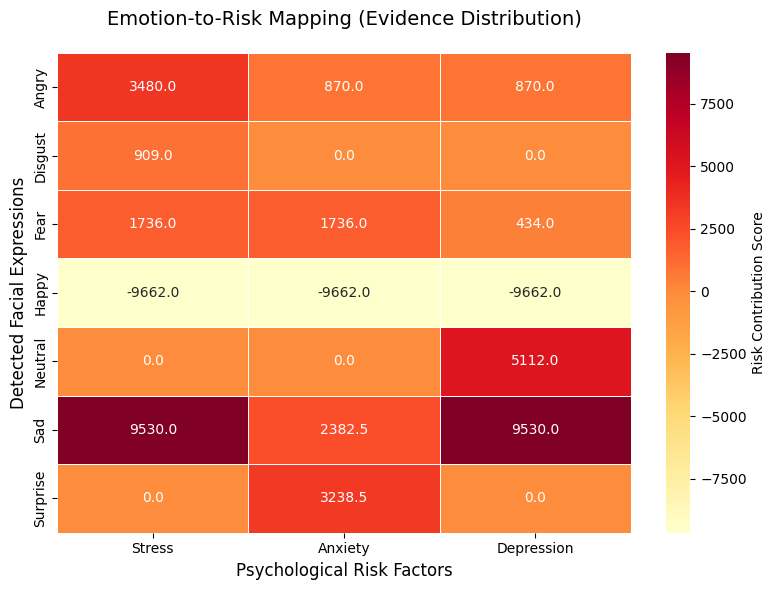

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ensure the dataset is unzipped if it's not already present
train_dir = "FER-2013/train"
if not os.path.exists(train_dir):
    print(f"Directory '{train_dir}' not found. Attempting to unzip Dataset.zip...")
    # Assuming Dataset.zip is in the current directory or accessible
    !unzip -q Dataset.zip

# Re-define classes (from cell a4)
classes = sorted(os.listdir(train_dir))

# Define the individual emotion weights for each risk factor (from cell PFBoxqkJfmGP)
stress_emotion_weights = {
    'angry': 2.0, 'fear': 2.0, 'sad': 2.0,
    'disgust': 1.0, 'surprise': 0.0, 'neutral': 0.0, 'happy': -2.0
}
anxiety_emotion_weights = {
    'angry': 0.5, 'fear': 2.0, 'sad': 0.5,
    'disgust': 0.0, 'surprise': 1.5, 'neutral': 0.0, 'happy': -2.0
}
depression_emotion_weights = {
    'angry': 0.5, 'fear': 0.5, 'sad': 2.0,
    'disgust': 0.0, 'surprise': 0.0, 'neutral': 1.0, 'happy': -2.0
}

# Construct the combined risk_weights dictionary
risk_weights = {}
for emotion in classes:
    risk_weights[emotion] = {
        'stress': stress_emotion_weights.get(emotion, 0.0),
        'anxiety': anxiety_emotion_weights.get(emotion, 0.0),
        'depression': depression_emotion_weights.get(emotion, 0.0)
    }

data_matrix = []

# Check if session_emotions is empty to avoid errors, and provide a default if so
if not session_emotions:
    # If no emotions were captured, create a dummy matrix for visualization
    # This ensures the heatmap can still render, albeit with zero values.
    for e in classes:
        data_matrix.append([0.0, 0.0, 0.0])
else:
    for e in classes:
        weights = risk_weights[e]
        count = session_emotions.count(e)
        data_matrix.append([weights['stress'] * count, weights['anxiety'] * count, weights['depression'] * count])

df_heatmap = pd.DataFrame(data_matrix, index=[c.capitalize() for c in classes], columns=['Stress', 'Anxiety', 'Depression'])

plt.figure(figsize=(8, 6))
sns.heatmap(df_heatmap, annot=True, cmap="YlOrRd", fmt=".1f", linewidths=0.5, cbar_kws={'label': 'Risk Contribution Score'})

plt.title("Emotion-to-Risk Mapping (Evidence Distribution)", fontsize=14, pad=20)
plt.xlabel("Psychological Risk Factors", fontsize=12)
plt.ylabel("Detected Facial Expressions", fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import accuracy_score

# You already have these from your previous code:
# test_preds, test_labels = get_preds(model, test_dl)

# Calculate exact accuracy
acc = accuracy_score(test_labels, test_preds)

print(f"Exact Model Accuracy: {acc * 100:.2f}%")

Exact Model Accuracy: 41.89%


In [36]:
import os

project_dir = '/content/drive/MyDrive/Emotion_Research_Project'
if not os.path.exists(project_dir):
    os.makedirs(project_dir)

torch.save(model.state_dict(), os.path.join(project_dir, 'emotion_model_weights.pth'))
print(f"Model saved to {project_dir}")

Model saved to /content/drive/MyDrive/Emotion_Research_Project
